# 1. Baseline 실험 - 기존 데이터셋 활용

본 노트북은 **기존 데이터셋만 사용**하여 MRC 모델을 학습하고 평가합니다.

**실험 목표:**
- 기존 학습 데이터셋의 성능 확인
- ETRI 외부 데이터셋과의 비교를 위한 베이스라인 구축
- 동일한 실험 환경에서의 공정한 비교 기반 마련


## 1.1. 환경 설정 및 라이브러리 Import


In [1]:
# 가상환경(.venv) 경로 자동 추가import sysfrom pathlib import Path# 프로젝트 루트 찾기project_root = Path().resolve().parent.parentvenv_path = project_root / ".venv"if venv_path.exists():    # Python 버전에 맞는 site-packages 경로 찾기    python_version = f"{sys.version_info.major}.{sys.version_info.minor}"    venv_site_packages = venv_path / "lib" / f"python{python_version}" / "site-packages"        # site-packages가 없으면 다른 가능한 경로 시도    if not venv_site_packages.exists():        lib_dir = venv_path / "lib"        if lib_dir.exists():            for py_dir in lib_dir.iterdir():                if py_dir.is_dir() and py_dir.name.startswith("python"):                    site_packages = py_dir / "site-packages"                    if site_packages.exists():                        venv_site_packages = site_packages                        break        if venv_site_packages.exists():        venv_path_str = str(venv_site_packages)        if venv_path_str not in sys.path:            sys.path.insert(0, venv_path_str)        print(f"✅ 가상환경(.venv) 경로 추가됨: {venv_site_packages}")    else:        print(f"⚠️ 가상환경(.venv)이 존재하지만 site-packages를 찾을 수 없습니다")else:    print(f"ℹ️ 가상환경(.venv)이 없습니다. 시스템 Python을 사용합니다")
# 노트북 독립 실행을 위한 환경 설정import sysfrom pathlib import Path# 프로젝트 루트를 sys.path에 추가project_root = Path().resolve().parent.parentif str(project_root) not in sys.path:    sys.path.insert(0, str(project_root))# 공통 유틸리티 importtry:    from notebooks.utils import setup_notebook_environment, load_dataset_safely, load_json_safely        # 환경 설정    paths = setup_notebook_environment()    print(f"✅ 프로젝트 루트: {paths['project_root']}")    print(f"✅ 데이터 디렉토리: {paths['data_dir']}")except ImportError as e:    print(f"⚠️ 유틸리티 import 실패: {e}")    paths = {        'project_root': project_root,        'data_dir': project_root / 'data',        'notebook_dir': project_root / 'notebooks'    }
# accelerate 버전 호환성 문제 해결 (필요시 실행)
%pip install --upgrade accelerate


Note: you may need to restart the kernel to use updated packages.


In [2]:
# OpenMP 충돌 방지 설정 (Windows 환경)
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'

# 필요한 라이브러리 import
import sys
import json
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from datasets import Dataset, DatasetDict, load_from_disk
from typing import List, Dict, Tuple, Optional
from tqdm.auto import tqdm
import re
import math
import evaluate
from dataclasses import dataclass, field

# Transformers
from transformers import (
    AutoConfig,
    AutoModelForQuestionAnswering,
    AutoTokenizer,
    DataCollatorWithPadding,
    EvalPrediction,
    TrainingArguments,
    Trainer,
    set_seed,
)

# 프로젝트 루트 경로 설정
project_root = Path().resolve().parent.parent
sys.path.append(str(project_root))

# src 모듈 import
from src.config import DataTrainingArguments, ModelArguments
from src.training.trainer_qa import QuestionAnsweringTrainer
from src.utils import postprocess_qa_predictions

# 시각화 설정
plt.rcParams['figure.figsize'] = (14, 8)
sns.set_style("whitegrid")

# 재현성을 위한 시드 설정
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"프로젝트 루트: {project_root}")
print(f"사용 디바이스: {device}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


d:\Repos\pro-nlp-mrc-nlp-01\.conda\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


프로젝트 루트: D:\Repos\pro-nlp-mrc-nlp-01
사용 디바이스: cuda
CUDA 사용 가능: True
GPU: NVIDIA GeForce RTX 2070


In [3]:
# 한글 폰트 설정
import matplotlib
import platform

def set_korean_font():
    system = platform.system()
    if system == 'Windows':
        font_name = 'Malgun Gothic'
    elif system == 'Darwin':  # Mac
        font_name = 'AppleGothic'
    else:  # Linux
        font_name = 'NanumGothic'
    matplotlib.rc('font', family=font_name)
    plt.rcParams['axes.unicode_minus'] = False

set_korean_font()


## 1.2. 데이터 로드


In [4]:
# 데이터 경로 설정
data_root = project_root / "data"
train_dataset_path = data_root / "train_dataset"
wikipedia_documents_path = data_root / "wikipedia_documents.json"

# 실험 결과 저장 경로
experiment_dir = Path().resolve() / "experiments" / "baseline"
experiment_dir.mkdir(parents=True, exist_ok=True)

# 데이터 로드
print("데이터셋 로드 중...")
train_datasets = load_from_disk(str(train_dataset_path))

with open(wikipedia_documents_path, 'r', encoding='utf-8') as f:
    wiki_documents = json.load(f)

print(f"Train dataset: {len(train_datasets['train'])} samples")
print(f"Validation dataset: {len(train_datasets['validation'])} samples")
print(f"Wikipedia documents: {len(wiki_documents)} documents")
print(f"\n데이터셋 컬럼: {train_datasets['train'].column_names}")


데이터셋 로드 중...
Train dataset: 3952 samples
Validation dataset: 240 samples
Wikipedia documents: 60613 documents

데이터셋 컬럼: ['title', 'context', 'question', 'id', 'answers', 'document_id', '__index_level_0__']


In [5]:
# 데이터 샘플 확인
print("=== 학습 데이터 샘플 ===")
sample = train_datasets['train'][0]
print(f"ID: {sample['id']}")
print(f"Question: {sample['question']}")
print(f"Context (처음 200자): {sample['context'][:200]}...")
print(f"Answer: {sample['answers']}")


=== 학습 데이터 샘플 ===
ID: mrc-1-000067
Question: 대통령을 포함한 미국의 행정부 견제권을 갖는 국가 기관은?
Context (처음 200자): 미국 상의원 또는 미국 상원(United States Senate)은 양원제인 미국 의회의 상원이다.\n\n미국 부통령이 상원의장이 된다. 각 주당 2명의 상원의원이 선출되어 100명의 상원의원으로 구성되어 있다. 임기는 6년이며, 2년마다 50개주 중 1/3씩 상원의원을 새로 선출하여 연방에 보낸다.\n\n미국 상원은 미국 하원과는 다르게 미국 대통령을 ...
Answer: {'answer_start': [235], 'text': ['하원']}


## 1.3. 모델 및 토크나이저 설정


In [6]:
# 모델 설정
MODEL_NAME = "klue/bert-base"
MAX_SEQ_LENGTH = 384
DOC_STRIDE = 128

# 토크나이저 및 모델 로드
print(f"모델 로드 중: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
model_config = AutoConfig.from_pretrained(MODEL_NAME)
model = AutoModelForQuestionAnswering.from_pretrained(MODEL_NAME, config=model_config)

print(f"토크나이저 vocab size: {tokenizer.vocab_size}")
print(f"모델 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")


모델 로드 중: klue/bert-base


Some weights of BertForQuestionAnswering were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


토크나이저 vocab size: 32000
모델 파라미터 수: 110,028,290


## 1.4. 데이터 전처리


In [7]:
# 데이터 전처리 함수
def prepare_train_features(examples):
    """학습 데이터 전처리"""
    tokenized = tokenizer(
        examples['question'],
        examples['context'],
        truncation="only_second",
        max_length=MAX_SEQ_LENGTH,
        stride=DOC_STRIDE,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
    )

    sample_mapping = tokenized.pop("overflow_to_sample_mapping")
    offset_mapping = tokenized.pop("offset_mapping")

    tokenized["start_positions"] = []
    tokenized["end_positions"] = []

    for i, offsets in enumerate(offset_mapping):
        input_ids = tokenized["input_ids"][i]
        cls_index = input_ids.index(tokenizer.cls_token_id)
        sequence_ids = tokenized.sequence_ids(i)
        sample_index = sample_mapping[i]
        answers = examples["answers"][sample_index]

        if len(answers["answer_start"]) == 0:
            tokenized["start_positions"].append(cls_index)
            tokenized["end_positions"].append(cls_index)
        else:
            start_char = answers["answer_start"][0]
            end_char = start_char + len(answers["text"][0])

            token_start_index = 0
            while sequence_ids[token_start_index] != 1:
                token_start_index += 1

            token_end_index = len(input_ids) - 1
            while sequence_ids[token_end_index] != 1:
                token_end_index -= 1

            if not (offsets[token_start_index][0] <= start_char and offsets[token_end_index][1] >= end_char):
                tokenized["start_positions"].append(cls_index)
                tokenized["end_positions"].append(cls_index)
            else:
                while token_start_index < len(offsets) and offsets[token_start_index][0] <= start_char:
                    token_start_index += 1
                tokenized["start_positions"].append(token_start_index - 1)

                while offsets[token_end_index][1] >= end_char:
                    token_end_index -= 1
                tokenized["end_positions"].append(token_end_index + 1)

    return tokenized


def prepare_validation_features(examples):
    """검증 데이터 전처리"""
    tokenized = tokenizer(
        examples['question'],
        examples['context'],
        truncation="only_second",
        max_length=MAX_SEQ_LENGTH,
        stride=DOC_STRIDE,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
    )

    sample_mapping = tokenized.pop("overflow_to_sample_mapping")
    tokenized["example_id"] = []

    for i in range(len(tokenized["input_ids"])):
        sequence_ids = tokenized.sequence_ids(i)
        sample_index = sample_mapping[i]
        tokenized["example_id"].append(examples["id"][sample_index])
        tokenized["offset_mapping"][i] = [
            (o if sequence_ids[k] == 1 else None)
            for k, o in enumerate(tokenized["offset_mapping"][i])
        ]

    return tokenized


In [8]:
# 데이터 전처리 수행
print("학습 데이터 전처리 중...")
train_dataset = train_datasets['train'].map(
    prepare_train_features,
    batched=True,
    remove_columns=train_datasets['train'].column_names
)

print("검증 데이터 전처리 중...")
validation_dataset = train_datasets['validation'].map(
    prepare_validation_features,
    batched=True,
    remove_columns=train_datasets['validation'].column_names
)

print(f"\n전처리된 학습 데이터 샘플 수: {len(train_dataset)}")
print(f"전처리된 검증 데이터 샘플 수: {len(validation_dataset)}")


학습 데이터 전처리 중...
검증 데이터 전처리 중...

전처리된 학습 데이터 샘플 수: 7978
전처리된 검증 데이터 샘플 수: 474


## 1.5. 학습 설정 및 실행


In [9]:
# 학습 인자 설정
training_args = TrainingArguments(
    output_dir=str(experiment_dir),
    do_train=True,
    do_eval=True,
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
)

# Data Collator
data_collator = DataCollatorWithPadding(
    tokenizer,
    pad_to_multiple_of=8 if training_args.fp16 else None
)

print("학습 설정 완료")
print(f"  - Learning Rate: {training_args.learning_rate}")
print(f"  - Batch Size: {training_args.per_device_train_batch_size}")
print(f"  - Epochs: {training_args.num_train_epochs}")
print(f"  - FP16: {training_args.fp16}")


학습 설정 완료
  - Learning Rate: 3e-05
  - Batch Size: 16
  - Epochs: 3
  - FP16: True


In [10]:
# 후처리 함수
def post_processing_function(examples, features, predictions, stage="eval"):
    """예측 결과 후처리"""
    predictions = postprocess_qa_predictions(
        examples=examples,
        features=features,
        predictions=predictions,
        max_answer_length=30,
        output_dir=str(experiment_dir),
    )
    
    formatted_predictions = [
        {"id": k, "prediction_text": v} for k, v in predictions.items()
    ]
    
    if stage == "predict":
        return formatted_predictions
    
    references = [
        {"id": ex["id"], "answers": ex["answers"]}
        for ex in train_datasets['validation']
    ]
    
    return EvalPrediction(
        predictions=formatted_predictions,
        label_ids=references
    )

# 메트릭 계산
metric = evaluate.load("squad")

def compute_metrics(p: EvalPrediction):
    result = metric.compute(predictions=p.predictions, references=p.label_ids)
    # Trainer가 eval_ 접두사가 붙은 메트릭을 기대하므로 접두사 추가
    return {f"eval_{k}": v for k, v in result.items()}


In [11]:
# Trainer 초기화
trainer = QuestionAnsweringTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    eval_examples=train_datasets['validation'],
    tokenizer=tokenizer,
    data_collator=data_collator,
    post_process_function=post_processing_function,
    compute_metrics=compute_metrics,
)

print("Trainer 초기화 완료")


D:\Repos\pro-nlp-mrc-nlp-01\src\training\trainer_qa.py:14: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `QuestionAnsweringTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


Trainer 초기화 완료


In [12]:
# 학습 실행
print("=" * 50)
print("Baseline 학습 시작")
print("=" * 50)

train_result = trainer.train()

# 모델 저장
trainer.save_model()

# 학습 결과 저장
metrics = train_result.metrics
trainer.log_metrics("train", metrics)
trainer.save_metrics("train", metrics)

print("\n학습 완료!")
print(f"Total Steps: {metrics.get('train_steps', 'N/A')}")
print(f"Train Loss: {metrics.get('train_loss', 'N/A'):.4f}")


Baseline 학습 시작


Epoch,Training Loss,Validation Loss,Exact Match,F1
1,1.096300,No log,56.250000,65.691288
2,0.595100,No log,54.583333,64.702531
3,0.271900,No log,59.583333,68.595058


d:\Repos\pro-nlp-mrc-nlp-01\.conda\lib\site-packages\transformers\trainer_pt_utils.py:476: FutureWarning: DistributedTensorGatherer is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
100%|██████████| 240/240 [00:03<00:00, 78.35it/s]
d:\Repos\pro-nlp-mrc-nlp-01\.conda\lib\site-packages\transformers\trainer_pt_utils.py:476: FutureWarning: DistributedTensorGatherer is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
100%|██████████| 240/240 [00:03<00:00, 71.86it/s]
d:\Repos\pro-nlp-mrc-nlp-01\.conda\lib\site-packages\transformers\trainer_pt_utils.py:476: FutureWarning: DistributedTensorGatherer is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
100%|██████████| 240/240 [00:03<00:00, 77.13it/s]


***** train metrics *****
  epoch                    =        3.0
  total_flos               =  4368282GF
  train_loss               =     0.9735
  train_runtime            = 0:07:33.08
  train_samples_per_second =     52.824
  train_steps_per_second   =      3.304

학습 완료!
Total Steps: N/A
Train Loss: 0.9735


## 1.6. 평가


In [13]:
# 평가 실행
print("=" * 50)
print("Baseline 평가 시작")
print("=" * 50)

eval_metrics = trainer.evaluate()

# 평가 결과 저장
trainer.log_metrics("eval", eval_metrics)
trainer.save_metrics("eval", eval_metrics)

print("\n=== Baseline 평가 결과 ===")
print(f"Exact Match (EM): {eval_metrics.get('eval_exact_match', 'N/A'):.2f}")
print(f"F1 Score: {eval_metrics.get('eval_f1', 'N/A'):.2f}")


Baseline 평가 시작


d:\Repos\pro-nlp-mrc-nlp-01\.conda\lib\site-packages\transformers\trainer_pt_utils.py:476: FutureWarning: DistributedTensorGatherer is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


100%|██████████| 240/240 [00:03<00:00, 77.19it/s]


***** eval metrics *****
  epoch            =     3.0
  eval_exact_match = 59.5833
  eval_f1          = 68.5951

=== Baseline 평가 결과 ===
Exact Match (EM): 59.58
F1 Score: 68.60


In [14]:
# 결과 요약 저장
results_summary = {
    "experiment": "baseline",
    "model": MODEL_NAME,
    "train_samples": len(train_datasets['train']),
    "eval_samples": len(train_datasets['validation']),
    "epochs": training_args.num_train_epochs,
    "learning_rate": training_args.learning_rate,
    "batch_size": training_args.per_device_train_batch_size,
    "eval_exact_match": eval_metrics.get('eval_exact_match'),
    "eval_f1": eval_metrics.get('eval_f1'),
}

results_path = experiment_dir / "results_summary.json"
with open(results_path, 'w', encoding='utf-8') as f:
    json.dump(results_summary, f, ensure_ascii=False, indent=2)

print(f"\n결과 요약이 저장되었습니다: {results_path}")



결과 요약이 저장되었습니다: D:\Repos\pro-nlp-mrc-nlp-01\notebooks\external_data_set\experiments\baseline\results_summary.json


## 1.7. 결과 시각화


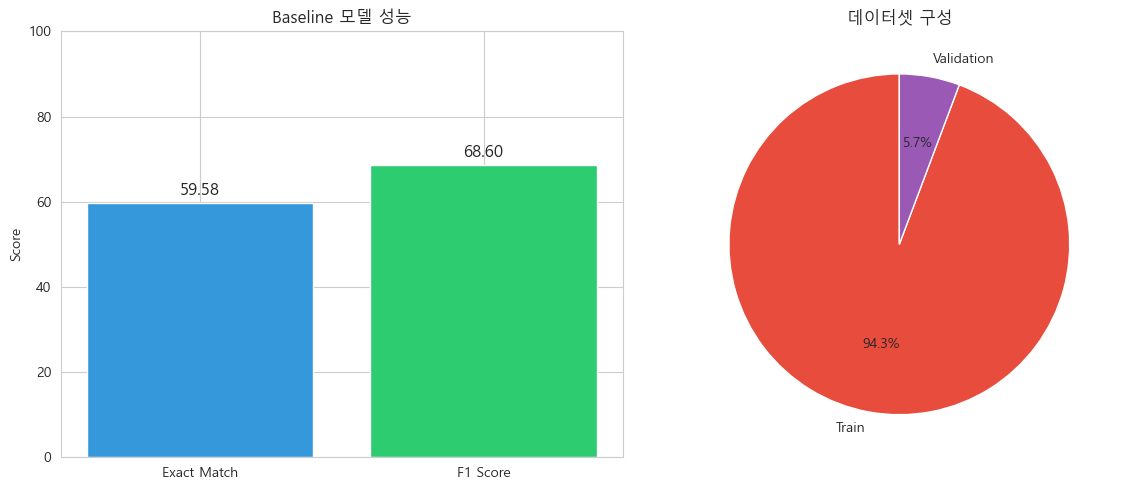


그래프 저장 완료: D:\Repos\pro-nlp-mrc-nlp-01\notebooks\external_data_set\experiments\baseline\baseline_results.png


In [15]:
# 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 메트릭 바 차트
metrics_names = ['Exact Match', 'F1 Score']
metrics_values = [
    eval_metrics.get('eval_exact_match', 0),
    eval_metrics.get('eval_f1', 0)
]

colors = ['#3498db', '#2ecc71']
bars = axes[0].bar(metrics_names, metrics_values, color=colors)
axes[0].set_ylabel('Score')
axes[0].set_title('Baseline 모델 성능')
axes[0].set_ylim(0, 100)

for bar, val in zip(bars, metrics_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=12)

# 데이터셋 정보
dataset_info = ['Train', 'Validation']
dataset_sizes = [len(train_datasets['train']), len(train_datasets['validation'])]

axes[1].pie(dataset_sizes, labels=dataset_info, autopct='%1.1f%%',
            colors=['#e74c3c', '#9b59b6'], startangle=90)
axes[1].set_title('데이터셋 구성')

plt.tight_layout()
plt.savefig(experiment_dir / "baseline_results.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n그래프 저장 완료: {experiment_dir / 'baseline_results.png'}")
